# Error Gating: does it induce a blocked preference?


In [1]:

import sys
import types
from pathlib import Path
from IPython.display import Image, display

# Work around a Python 3.13 torch import crash in this conda env.
if 'rlcompleter' not in sys.modules:
    rlcompleter = types.ModuleType('rlcompleter')
    rlcompleter.Completer = type(
        'Completer',
        (),
        {
            '__init__': lambda self, namespace=None: None,
            'complete': lambda self, text, state: None,
        },
    )
    sys.modules['rlcompleter'] = rlcompleter

import pandas as pd
import numpy as np
from experimental_setups import error_gating_model, isc_model
import data
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from experimental_setups.error_gating_model import *


## Updated Error-Gating Experiment


In [2]:
run_number = 3
results_path = Path(f'data/error_baseline_comparison_v{run_number}.csv')
lc_path = Path(f'data/error_learning_curves_v{run_number}.csv')
plot_dir = Path(f'images/error_gating_v{run_number}')
plot_dir.mkdir(parents=True, exist_ok=True)

force_rerun = True
num_epochs = 40

needs_rerun = (
    force_rerun
    or not results_path.exists()
    or not lc_path.exists()
)

if not needs_rerun:
    lc_probe = pd.read_csv(lc_path, nrows=1)
    needs_rerun = not {'c1', 'c2'}.issubset(lc_probe.columns)

if needs_rerun:
    print('Now training error-gating model...')
    hebb_errors, hebb_lc = run_error_experiment(
        num_epochs=num_epochs,
        track_learning_curves=True,
        save_models=True,
    )
    print('	...finished error-gating model!')

    print('Now training/loading ISC baseline...')
    error_data = hebb_errors + run_error_baseline(num_epochs=num_epochs)
    error_data = pd.concat(error_data, axis=0, ignore_index=True)
    error_data.to_csv(results_path, index=False)

    lc_df = pd.concat(hebb_lc, axis=0, ignore_index=True)
    lc_df.to_csv(lc_path, index=False)
    print('	...finished baseline and saved CSVs!')
else:
    print('Using cached experiment CSVs.')

lc_df = pd.read_csv(lc_path)
results_df = pd.read_csv(results_path)

lc_df['epoch'] = lc_df['epoch'].astype(int)
lc_df['bce'] = lc_df['bce'].astype(float)
lc_df[['c1', 'c2']] = lc_df[['c1', 'c2']].astype(float)

print(lc_df.head())
print(results_df.head())


Now training error-gating model...
	...finished error-gating model!
Now training/loading ISC baseline...
	...finished baseline and saved CSVs!
   model  epoch       bce        c1        c2    condition architecture
0      0      0  0.018439  0.007751  0.006259  interleaved      Hebbian
1      0      1  0.018041  0.038666  0.031226  interleaved      Hebbian
2      0      2  0.019178  0.048265  0.038982  interleaved      Hebbian
3      0      3  0.018101  0.063016  0.050911  interleaved      Hebbian
4      0      4  0.018309  0.072982  0.058976  interleaved      Hebbian
   model  acc architecture    condition  lr_hebb
0      0  1.0      Hebbian  interleaved     0.01
1      0  1.0      Hebbian  interleaved     0.01
2      0  1.0      Hebbian  interleaved     0.01
3      0  1.0      Hebbian  interleaved     0.01
4      0  1.0      Hebbian  interleaved     0.01


## Learning Curves and Context-Input-to-CD Weights


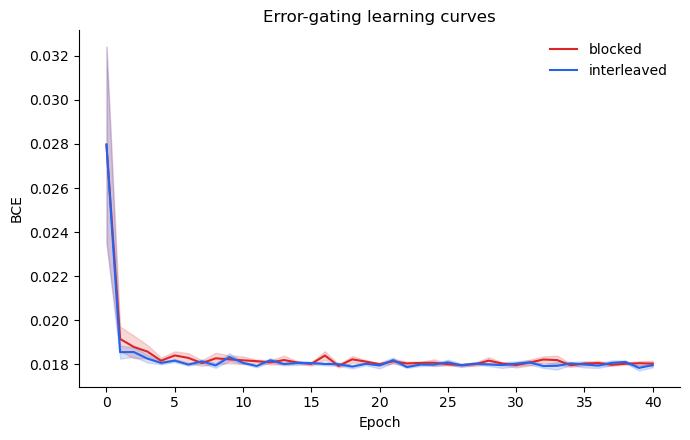

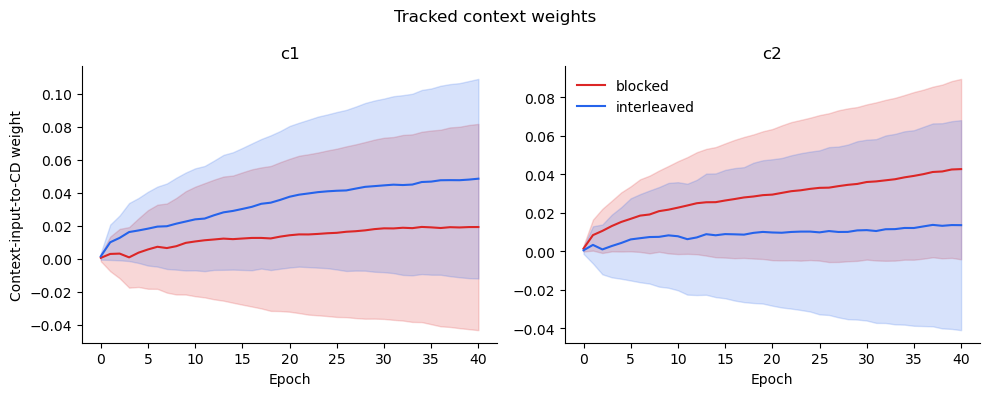

In [3]:

lc_summary = lc_df.groupby(['condition', 'epoch'], as_index=False).agg(
    bce_mean=('bce', 'mean'),
    bce_sem=('bce', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    c1_mean=('c1', 'mean'),
    c1_sem=('c1', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    c2_mean=('c2', 'mean'),
    c2_sem=('c2', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
)

colors = {'interleaved': '#2563eb', 'blocked': '#dc2626'}

fig, ax = plt.subplots(figsize=(7, 4.5))
for condition, condition_df in lc_summary.groupby('condition'):
    ax.plot(
        condition_df['epoch'],
        condition_df['bce_mean'],
        label=condition,
        color=colors.get(condition),
    )
    ax.fill_between(
        condition_df['epoch'],
        condition_df['bce_mean'] - condition_df['bce_sem'],
        condition_df['bce_mean'] + condition_df['bce_sem'],
        color=colors.get(condition),
        alpha=0.18,
    )

ax.set_xlabel('Epoch')
ax.set_ylabel('BCE')
ax.set_title('Error-gating learning curves')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(plot_dir / 'error_learning_curves.png', dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, weight in zip(axes, ['c1', 'c2']):
    for condition, condition_df in lc_summary.groupby('condition'):
        mean = condition_df[f'{weight}_mean']
        sem = condition_df[f'{weight}_sem']
        ax.plot(condition_df['epoch'], mean, label=condition, color=colors.get(condition))
        ax.fill_between(
            condition_df['epoch'],
            mean - sem,
            mean + sem,
            color=colors.get(condition),
            alpha=0.18,
        )
    ax.set_title(weight)
    ax.set_xlabel('Epoch')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Context-input-to-CD weight')
axes[1].legend(frameon=False)
fig.suptitle('Tracked context weights')
fig.tight_layout()
fig.savefig(plot_dir / 'context_weight_traces.png', dpi=200)
plt.show()


## Error-Gating vs ISC Baseline


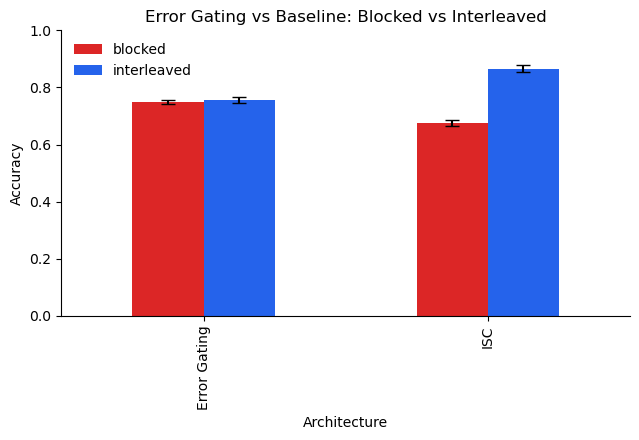

In [4]:

model_means = results_df.groupby(['architecture', 'condition', 'model'])['acc'].mean()
stats = model_means.groupby(['architecture', 'condition']).agg(['mean', 'std'])

plot_data = stats['mean'].unstack('condition').loc[['Hebbian', 'ISC']]
plot_err = stats['std'].unstack('condition').loc[['Hebbian', 'ISC']]
plot_data.index = ['Error Gating', 'ISC']
plot_err.index = plot_data.index

fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_data[['blocked', 'interleaved']].plot(
    kind='bar',
    yerr=plot_err[['blocked', 'interleaved']],
    capsize=5,
    ax=ax,
    color=[colors['blocked'], colors['interleaved']],
)

ax.set_xlabel('Architecture')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('Error Gating vs Baseline: Blocked vs Interleaved')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='', frameon=False)
fig.tight_layout()
fig.savefig(plot_dir / 'error_baseline_comparison.png', dpi=200)
plt.show()


## Error-gated circuit as a drop-in Oja-pathway replacement

This test loads both actual Oja curriculum checkpoint families—`oja_a0.87_blockd-*.torch` and `oja_a0.87_interl-*.torch`—and does **no additional training**. Every network receives the same 380-trial evaluation sequence, so blocked versus interleaved denotes training history rather than repeated behavioral-test labels. At inference it compares supplied context, zero context, and an item-only error-gated controller. The replacement never receives the external context tensor. Statistics are paired across model seeds within each training curriculum.


In [ ]:
from pathlib import Path

from experimental_setups.error_gating_model.dropin_oja_experiment import (
    ErrorGatedOjaPathway,
    curriculum_paired_tests,
    plot_curriculum_breakdown,
    run_curriculum_experiment,
)

# ErrorGatedOjaPathway.forward_item(item) deliberately has no context argument.
dropin_results = run_curriculum_experiment(
    model_dir=Path('models'),
    num_models=10,
    device='cpu',
)
dropin_results.head()


In [ ]:
dropin_tests = curriculum_paired_tests(dropin_results)

dropin_results_path = Path('data/error_gated_oja_dropin_by_curriculum.csv')
dropin_tests_path = Path('data/error_gated_oja_dropin_curriculum_tests.csv')
dropin_plot_path = Path('images/error_gating_oja_dropin_by_curriculum.png')
dropin_results.to_csv(dropin_results_path, index=False)
dropin_tests.to_csv(dropin_tests_path, index=False)
plot_curriculum_breakdown(dropin_results, dropin_plot_path)
display(dropin_tests)
display(Image(filename=dropin_plot_path))


### Corrected result: 10 seeds per training curriculum

For **blocked-trained networks**, accuracy was 83.76% with the replacement, 83.42% with zero context, and 84.08% with supplied context. Neither replacement contrast was significant by classification error (vs zero: $p=.274$; vs supplied: $p=.370$).

For **interleaved-trained networks**, accuracy was 83.21% with the replacement, 82.58% with zero context, and 84.42% with supplied context. The replacement-versus-zero improvement did not reach significance ($p=.074$), while supplied context significantly outperformed the replacement ($p=.000964$).

![Corrected Oja curriculum breakdown](images/error_gating_oja_dropin_by_curriculum.png)


### Seed-level paired tests within each training curriculum


In [ ]:
from experimental_setups.error_gating_model.dropin_oja_experiment import (
    curriculum_paired_tests,
    plot_curriculum_breakdown,
)

dropin_block_tests = curriculum_paired_tests(dropin_results)
dropin_block_tests_path = Path('data/error_gated_oja_dropin_curriculum_tests.csv')
dropin_block_plot_path = Path('images/error_gating_oja_dropin_by_curriculum.png')
dropin_block_tests.to_csv(dropin_block_tests_path, index=False)
plot_curriculum_breakdown(dropin_results, dropin_block_plot_path)
display(dropin_block_tests)
display(Image(filename=dropin_block_plot_path))


The previous version incorrectly grouped duplicated behavioral evaluation labels. Since zero context ignores those labels and the item/target sequence repeats, identical blocked/interleaved values were guaranteed. Here, `training_condition` comes directly from each checkpoint filename and the same evaluation trials are used for both families.

The corrected analysis provides no significant evidence that the error-gated drop-in improves classification error over zero context in either curriculum at $n=10$.

![Blocked versus interleaved training accuracy](images/error_gating_oja_dropin_by_curriculum.png)
